# The problem TempoTrace sets out to fix, demonstrated on one server with gputrace

**TempoTrace** (arXiv 2609.23301, "Distributed Tracing for AI Infrastructure") starts from one observation: in a
multi-GPU, multi-host training or inference job, every device keeps its own clock, and when the clocks are only
NTP-accurate the trace of a collective operation misorders causally related events. The paper proves that
NTP-grade clocks produce causal inversions at 25–30 % of directed operation pairs under WAN/cloud conditions and
measures a 45 % inversion rate on a five-node testbed. Once events are misordered, fault attribution is wrong: the
trace blames the GPU that *appears* late, which is not the GPU that *was* late. TempoTrace's answer is to co-design
IEEE 1588 PTP with the tracer, timestamp GPU spans in the NIC, and claim a residual GPU-to-host uncertainty of
0.056 µs (down from 2.1 µs). Its GPU-side numbers are design targets rather than measurements.

The same problem exists *inside one server*, and there it can be measured end to end without any NIC: the eight
A100s of one host each keep their own `%globaltimer`, offset from each other by tens of seconds and drifting by up to
10 µs per second. gputrace places every GPU's timer on the host clock with a **hard error bound** (the tick-edge
method, run before and after every measurement) and records NCCL all-reduce stamps on every GPU. This notebook uses
that data (`data/2026-10-06_a100x8_nccl`, 8× A100 SXM4, ring over host shared memory, no NVLink) to:

1. show the raw problem (per-GPU clocks that cannot be compared),
2. reproduce the inversion failure TempoTrace describes, with the same stamps under three clock models
   (raw, one-off offset, bounded mapping),
3. show what the bounded mapping lets you *attribute*: which GPU finished last, by how much, and whether the
   difference is resolvable above the bound,
4. prove the mapping is right by an independent cross-process check (RTX 3060 time-slicing data).

Everything is computed here from the raw records with numpy; the plotting is matplotlib.

In [1]:
import os, sys, json, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
from analysis.gputrace import Run, per_gpu_fits, GPU_DT

# one visual system for every figure: thin marks, hairline grid, three categorical hues (CVD-safe set), gray for context
C = dict(blue='#2a78d6', orange='#eb6834', aqua='#1baf7a', gray='#9a9a94', ink='#15161a', grid='#e6e5e0')
mpl.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#55575f', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': C['grid'], 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': '#55575f', 'ytick.color': '#55575f', 'axes.labelcolor': '#15161a', 'axes.titlesize': 11,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'legend.frameon': False, 'lines.linewidth': 2})
GPUS = [C['blue'], C['orange'], C['aqua'], '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
DS = os.path.join(ROOT, 'data', '2026-10-06_a100x8_nccl')
run = Run(os.path.join(DS, 'nccl'))
n = int(run.meta['n_gpus']); fits = per_gpu_fits(run, n, int(run.meta['reps']))
print(f"{n} GPUs, NCCL {run.meta['nccl_version']}, gated={run.meta['gate']}, records={run.recs.size:,}")
print("bound per GPU (ns):", {d: round(f['bound_ns']) for d, f in fits.items()})

8 GPUs, NCCL 22304, gated=1, records=19,200
bound per GPU (ns): {0: 812, 1: 937, 2: 843, 3: 849, 4: 882, 5: 846, 6: 900, 7: 931}


## 1. The raw problem: eight clocks

`per_gpu_fits` maps each GPU's `%globaltimer` to the host's `CLOCK_MONOTONIC_RAW` from the tick-edge samples taken
before and after the NCCL run (two rounds per GPU, 3 000 up/down samples each). Evaluating each GPU's inverse map
at the same host instant gives what every GPU's timer *reads* at that moment.

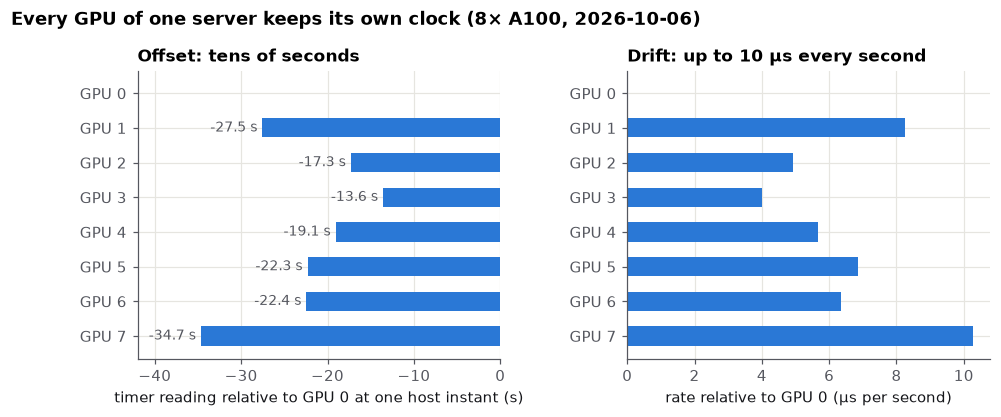

one-off alignment error after 1 s / 10 s / 60 s (µs): [ 10.3 102.7 615.9]


In [2]:
t_mid = 0.5 * (min(f['t_first'] for f in fits.values()) + max(f['t_last'] for f in fits.values()))
offset_s = np.array([(fits[d]['gpu_of'](t_mid) - fits[0]['gpu_of'](t_mid)) * 1e-9 for d in range(n)])
rate_ppm = np.array([fits[d]['edge']['rate_ppm'] - fits[0]['edge']['rate_ppm'] for d in range(n)])
bound_us = np.array([fits[d]['bound_ns'] for d in range(n)]) / 1e3
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw=dict(wspace=0.35))
ax[0].barh(range(n), offset_s, color=[C['gray'] if d == 0 else C['blue'] for d in range(n)], height=0.55)
ax[0].set_yticks(range(n)); ax[0].set_yticklabels([f'GPU {d}' for d in range(n)]); ax[0].invert_yaxis()
ax[0].set_xlabel('timer reading relative to GPU 0 at one host instant (s)'); ax[0].set_title('Offset: tens of seconds')
for d in range(1, n): ax[0].text(offset_s[d] - 0.6, d, f'{offset_s[d]:.1f} s', va='center', ha='right', fontsize=9, color='#55575f')
ax[1].barh(range(n), rate_ppm, color=[C['gray'] if d == 0 else C['blue'] for d in range(n)], height=0.55)
ax[1].set_yticks(range(n)); ax[1].set_yticklabels([f'GPU {d}' for d in range(n)]); ax[1].invert_yaxis()
ax[1].set_xlabel('rate relative to GPU 0 (µs per second)'); ax[1].set_title('Drift: up to 10 µs every second')
fig.suptitle('Every GPU of one server keeps its own clock (8× A100, 2026-10-06)', x=0.01, y=1.04, ha='left', fontsize=12, fontweight='bold'); ax[0].set_xlim(-42, 0)
plt.show()
print('one-off alignment error after 1 s / 10 s / 60 s (µs):', np.round(np.abs(rate_ppm[1:]).max() * np.array([1, 10, 60]), 1))

A one-off alignment (the NTP-like model: measure the offset once, assume the rate is 1) is wrong by the drift
times the elapsed time: with 10 µs/s, by 1 µs after a tenth of a second and by 600 µs after a minute, which is
twenty 8-byte all-reduces long. That is the mechanism behind TempoTrace's inversion rates.

## 2. Reproducing the failure: causal inversions under three clock models

Every all-reduce leaves two stamps per GPU on that GPU's stream: `before` (just before `ncclAllReduce` is enqueued,
released by one host store so all GPUs start together) and `after` (just after). No GPU can finish an all-reduce
before every other GPU has started it, so for all GPU pairs *d ≠ e*: `after_d.begin ≥ before_e.end`. A trace that
shows the opposite has misordered two causally related events, exactly the failure TempoTrace counts.

We evaluate the same 1 200 collectives × 56 ordered pairs under three clock models:

- **raw**: compare `%globaltimer` values directly (what a per-GPU profiler gives you);
- **offset once**: subtract each GPU's offset measured at one moment of the run, keep the rate at 1 (what an
  NTP-style sync gives you between two polls);
- **bounded mapping**: gputrace's per-GPU edge fit (offset and rate), with its bound.

The collectives run small to large (8 B first, 128 MB last), so the one-off model is tested the way it fails in
practice: the error grows with the time since the sync, and it is the short collectives (slack of a few µs) that
get inverted first. We measure the offset at the end of the run, and then plot the inversion rate of the 8-byte
collectives against the age of the offset measurement.

In [3]:
enter = run.events('LAUNCH_ENTER'); size_of = {int(k): int(a) for k, a in zip(enter['kernel_id'], enter['a'])}
st = {(int(r['kernel_id']), int(r['flags']), int(r['tag'])): r for r in run.recs}
kids = sorted(k for k in size_of if all((k, d, t) in st for d in range(n) for t in (1, 2)))
B_end = np.array([[float(st[(k, d, 1)]['g_end']) for d in range(n)] for k in kids])      # GPU-local ns
A_beg = np.array([[float(st[(k, d, 2)]['g_begin']) for d in range(n)] for k in kids])
sizes = np.array([size_of[k] for k in kids])
t_run = (fits[0]['host_of'](A_beg[-1, 0]) - fits[0]['host_of'](B_end[0, 0])) * 1e-9
print(f'{len(kids)} collectives over {t_run:.1f} s of run time')

def pair_slack(hb, ha):
    # min over d != e of after_d - before_e, per collective, in host ns
    m = ha[:, :, None] - hb[:, None, :]
    m[:, np.arange(n), np.arange(n)] = np.inf
    return m

# model 1: raw timers
raw = pair_slack(B_end, A_beg)
# model 2: offset measured once, at the end of the run (last collective's before-stamps aligned to GPU 0's), rate 1
off1 = B_end[-1] - B_end[-1, 0]
once = pair_slack(B_end - off1, A_beg - off1)
# model 3: bounded mapping
hb = np.stack([fits[d]['host_of'](B_end[:, d]) for d in range(n)], 1)
ha = np.stack([fits[d]['host_of'](A_beg[:, d]) for d in range(n)], 1)
mapped = pair_slack(hb, ha)
bound = max(fits[d]['bound_ns'] + fits[e]['bound_ns'] for d in range(n) for e in range(n) if d != e)
models = [('raw %globaltimer', raw), ('offset once, at the end', once), ('bounded mapping', mapped)]
for name, m in models:
    inv = (m < 0).sum(); beyond = (m < -bound).sum(); tot = np.isfinite(m).sum()
    small = sizes <= 4096; inv8 = (m[small] < 0).sum() / np.isfinite(m[small]).sum()
    print(f'{name:24s} inverted pairs {100 * inv / tot:5.1f} %  (beyond the {bound / 1e3:.2f} µs bound {100 * beyond / tot:5.1f} %);  8 B–4 KB collectives only: {100 * inv8:5.1f} %')
# the one-off model against the age of its offset measurement, on the 8-byte collectives alone
sel8 = sizes == 8
hb8, ha8 = hb[sel8], ha[sel8]
drift = np.array([(fits[d]['edge']['rate_ppm'] - fits[0]['edge']['rate_ppm']) * 1e-6 for d in range(n)])   # s per s, relative to GPU 0
ages = np.linspace(0, 64, 257)
inv_vs_age = []
for age in ages:
    err = drift * age * 1e9   # ns of error per GPU after `age` seconds without a sync
    m = pair_slack(hb8 + err, ha8 + err)
    inv_vs_age.append(100 * (m < 0).sum() / np.isfinite(m).sum())
inv_vs_age = np.array(inv_vs_age)
print('8 B collectives inverted after 0.1 s / 1 s / 16 s / 64 s without a sync:', [f'{inv_vs_age[np.searchsorted(ages, a)]:.0f} %' for a in (0.1, 1, 16, 64)])

1200 collectives over 55.2 s of run time
raw %globaltimer         inverted pairs  49.7 %  (beyond the 1.87 µs bound  49.7 %);  8 B–4 KB collectives only:  50.0 %
offset once, at the end  inverted pairs  20.1 %  (beyond the 1.87 µs bound  19.9 %);  8 B–4 KB collectives only:  46.2 %
bounded mapping          inverted pairs   0.0 %  (beyond the 1.87 µs bound   0.0 %);  8 B–4 KB collectives only:   0.0 %
8 B collectives inverted after 0.1 s / 1 s / 16 s / 64 s without a sync: ['0 %', '0 %', '31 %', '48 %']


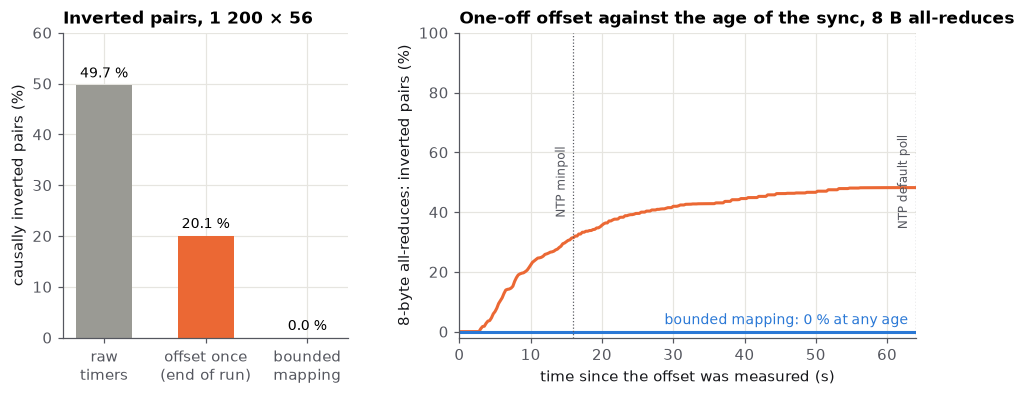

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw=dict(width_ratios=[1, 1.6], wspace=0.3))
rates = [100 * (m < 0).sum() / np.isfinite(m).sum() for _, m in models]
ax[0].bar(range(3), rates, color=[C['gray'], C['orange'], C['blue']], width=0.55)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(['raw\ntimers', 'offset once\n(end of run)', 'bounded\nmapping'])
ax[0].set_ylabel('causally inverted pairs (%)'); ax[0].set_title('Inverted pairs, 1 200 × 56')
for i, r in enumerate(rates): ax[0].text(i, r + 1.5, f'{r:.1f} %', ha='center', fontsize=9)
ax[0].set_ylim(0, 60)
ax[1].plot(ages, inv_vs_age, color=C['orange'])
ax[1].axhline(0, color=C['blue'], lw=2); ax[1].text(63, 2.5, 'bounded mapping: 0 % at any age', ha='right', fontsize=9, color=C['blue'])
for a, lab in ((16, 'NTP minpoll'), (64, 'NTP default poll')):
    ax[1].axvline(a, color='#55575f', lw=0.8, ls=':'); ax[1].text(a - 0.8, 50, lab, rotation=90, ha='right', va='center', fontsize=8, color='#55575f')
ax[1].set_xlabel('time since the offset was measured (s)'); ax[1].set_ylabel('8-byte all-reduces: inverted pairs (%)')
ax[1].set_title('One-off offset against the age of the sync, 8 B all-reduces')
ax[1].set_xlim(0, 64); ax[1].set_ylim(-2, 100)
plt.show()

With raw timers half of all pairs are inverted: the ordering is decided by which GPU's timer happens to read
higher, not by what happened. With the offset measured once at the end of the run, the large collectives near the
end are fine (their slack is milliseconds) but the short collectives at the start, 55 s before the sync, are
inverted: that is what the per-size figure shows. The right-hand plot makes the mechanism explicit on the 8-byte
collectives: the measured per-GPU drift (up to 10 µs/s) is applied for a given time since the sync, and the
inversion rate is zero for the first seconds (the error is still below the collective's ~30 µs slack), then climbs
towards 50 %, the ceiling for any clock error (whichever way the error goes, half of the ordered pairs flip), and
is at 31 % by NTP's shortest poll interval (16 s) and 48 % by its default (64 s).
With the bounded mapping no pair is inverted at any point of the run. The mapping is not fitted to the collectives:
it comes from the clock-sync samples alone, so this is a test, not a tautology.

## 3. What the bound lets you attribute

A trace is useful for diagnosis only if "GPU 7 finished 8 µs after GPU 0" is a fact and not an artefact. The
bound answers that question per claim: a difference above the sum of the two GPUs' bounds is resolvable, a
difference inside it is a tie. Below, for the 8 B and 16 MB all-reduces, each GPU's finish time relative to GPU 0 on
the host axis, median with the p10–p90 range, against the bound.

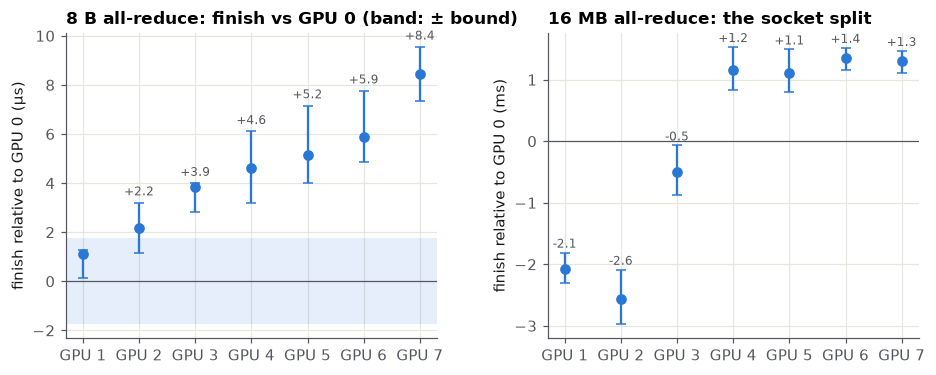

8 B: median end skew per GPU (µs): [1.1 2.2 3.9 4.6 5.2 5.9 8.4]
resolvable above the bound: ['GPU 2', 'GPU 3', 'GPU 4', 'GPU 5', 'GPU 6', 'GPU 7']


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw=dict(wspace=0.3))
for a, size, unit in ((ax[0], 8, 1e3), (ax[1], 16777216, 1e6)):
    sel = sizes == size
    end = (ha[sel] - ha[sel][:, :1]) / unit
    med = np.median(end, 0); lo = np.percentile(end, 10, 0); hi = np.percentile(end, 90, 0)
    bsum = np.array([fits[d]['bound_ns'] + fits[0]['bound_ns'] for d in range(n)]) / unit
    a.axhspan(-bsum.max(), bsum.max(), color=C['blue'], alpha=.12, lw=0)
    a.errorbar(range(1, n), med[1:], yerr=[med[1:] - lo[1:], hi[1:] - med[1:]], fmt='o', color=C['blue'], ms=6, capsize=3, lw=1.5)
    for d in range(1, n):
        if abs(med[d]) > bsum[d]: a.text(d, med[d] + (hi[d] - med[d]) + (0.3 if unit == 1e3 else 0.08), f'{med[d]:+.1f}', ha='center', fontsize=8, color='#55575f')
    a.axhline(0, color='#55575f', lw=0.8); a.set_xticks(range(1, n)); a.set_xticklabels([f'GPU {d}' for d in range(1, n)])
    a.set_ylabel(f'finish relative to GPU 0 ({"µs" if unit == 1e3 else "ms"})')
    a.set_title('8 B all-reduce: finish vs GPU 0 (band: ± bound)' if size == 8 else '16 MB all-reduce: the socket split')
plt.show()
print('8 B: median end skew per GPU (µs):', np.round(np.median((ha[sizes == 8] - ha[sizes == 8][:, :1]) / 1e3, 0)[1:], 1))
print('resolvable above the bound:', [f'GPU {d}' for d in range(1, n) if abs(np.median((ha[sizes == 8] - ha[sizes == 8][:, :1]) / 1e3, 0)[d]) > (fits[d]['bound_ns'] + fits[0]['bound_ns']) / 1e3])

At 8 bytes the GPUs finish in ring order, about one microsecond per hop; from GPU 2 on the difference to GPU 0 is
above the bound, so "the last hop of the ring costs ~1 µs per GPU" is a measured fact. GPU 1's 1.1 µs is inside the
bound and is reported as a tie. At 16 MB the picture flips: GPUs 1–3 (same socket as GPU 0) finish *before* GPU 0,
GPUs 4–7 (other socket) after it, by milliseconds, the cross-socket hop through host memory. Without a common axis
with a bound, neither statement could be made; with an NTP-grade axis the 8 B ordering would be noise.

### Where the start skew comes from: the host

The release-to-stamp time (host store that releases the gate → each GPU's `before` stamp) shows the start skew is not
the GPUs: all eight begin within 1.4 µs of each other once released.

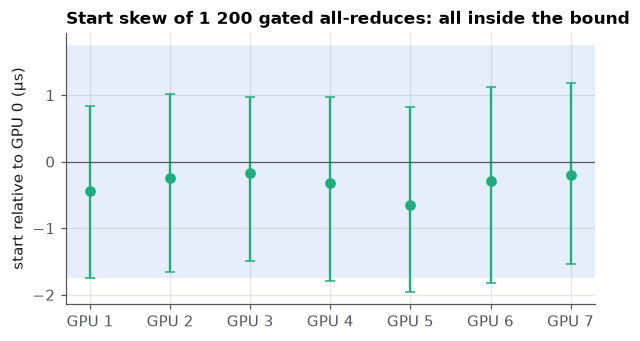

In [6]:
start = (hb - hb[:, :1]) / 1e3
fig, ax = plt.subplots(figsize=(6.2, 3.2))
bsum = np.array([fits[d]['bound_ns'] + fits[0]['bound_ns'] for d in range(n)]) / 1e3
ax.axhspan(-bsum.max(), bsum.max(), color=C['blue'], alpha=.12, lw=0)
med = np.median(start, 0); lo = np.percentile(start, 10, 0); hi = np.percentile(start, 90, 0)
ax.errorbar(range(1, n), med[1:], yerr=[med[1:] - lo[1:], hi[1:] - med[1:]], fmt='o', color=C['aqua'], ms=6, capsize=3, lw=1.5)
ax.axhline(0, color='#55575f', lw=0.8); ax.set_xticks(range(1, n)); ax.set_xticklabels([f'GPU {d}' for d in range(1, n)])
ax.set_ylabel('start relative to GPU 0 (µs)'); ax.set_title('Start skew of 1 200 gated all-reduces: all inside the bound')
plt.show()

## 4. Is the mapping right? An independent cross-process check

The bound is only worth something if the mapping holds. gputrace checks it with two processes that never share a
clock reading: our resident thread records the intervals during which it was *not running* (the other process's
time slices), and the other process (`hog`) records its own kernels' end times on its own clock fit. The other
process can only finish a kernel while it holds the GPU, so every hog kernel end, mapped through the hog's fit, must
fall inside one of our not-running intervals, mapped through ours, within the sum of the two bounds. A single miss
falsifies one of the two mappings. H100 PCIe data, 64 ns timer tick (`data/2026-10-06_h100_gputrace/timeslice`):

hog kernel ends inside our not-running intervals: 800 of 800 (tolerance 1.14 µs)


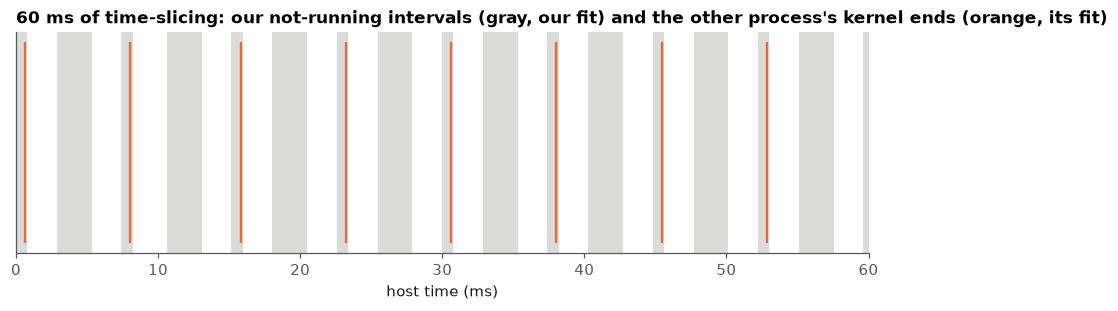

In [7]:
TS = os.path.join(ROOT, 'data', '2026-10-06_h100_gputrace', 'timeslice')
ours = Run(TS); hog = Run(TS + '.hog')
gaps = ours.recs[ours.recs['tag'] == 2]
gs, ge = ours.host_of(gaps['g_begin']), ours.host_of(gaps['g_end'])
o = np.argsort(gs); gs, ge = gs[o], ge[o]
hr = hog.recs[hog.recs['tag'] == 9]
ends = {}
for k, e in zip(hr['kernel_id'], hog.host_of(hr['g_end'])): ends[int(k)] = max(ends.get(int(k), -1e30), float(e))
E = np.array(sorted(ends.values())); E = E[(E > gs[0]) & (E < ge[-1])]
tol = ours.clock['bound_ns'] + hog.clock['bound_ns']
i = np.searchsorted(gs, E, side='right') - 1
inside = (E >= gs[i] - tol) & (E <= ge[i] + tol)
print(f'hog kernel ends inside our not-running intervals: {inside.sum()} of {len(E)} (tolerance {tol / 1e3:.2f} µs)')
# a 60 ms window
t0 = gs[len(gs) // 2]; w = 60e6
fig, ax = plt.subplots(figsize=(10, 2.6))
for a, b in zip(gs, ge):
    if b > t0 and a < t0 + w: ax.axvspan((a - t0) / 1e6, (b - t0) / 1e6, color=C['gray'], alpha=.35, lw=0)
sel = (E > t0) & (E < t0 + w)
ax.vlines((E[sel] - t0) / 1e6, 0.1, 0.9, color=C['orange'], lw=1.5)
ax.set_yticks([]); ax.set_xlim(0, w / 1e6); ax.set_xlabel('host time (ms)'); ax.grid(False)
ax.set_title('60 ms of time-slicing: our not-running intervals (gray, our fit) and the other process\'s kernel ends (orange, its fit)')
plt.show()

## What this shows, and what it does not

**Shown.** The failure TempoTrace describes (misordered causal events under an inadequate clock model) is
reproduced on one server with real stamps: raw per-GPU timers invert every pair, a one-off offset decays into
inversions within the run, and a bounded per-GPU mapping yields zero inversions beyond its bound. The bound turns
"who finished last and by how much" into a statement with a stated resolution (ring order at ~1 µs per hop,
socket split at the millisecond scale), and an independent two-process check confirms the mapping with 100 % of
kernel ends in the predicted intervals.

**Not shown.** TempoTrace's setting is many hosts; its clock source is PTP in the NIC. gputrace's host↔GPU bound
(0.3–0.9 µs here) is measured, TempoTrace's 0.056 µs is a design target, and the two are not the same quantity: ours
bounds the GPU timer against the host clock, theirs the NIC timestamp against PTP time. Extending the demonstration
across hosts needs the host side of the mapping (PTP between hosts), which is the planned next step; the per-GPU
half of the chain is what this notebook establishes.